In [21]:
import numpy as np
import pandas as pd
import glob  # For getting all csvs with one path
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
files = glob.glob('posts_*.csv')

df_list = []
for filename in files:
  temp_df = pd.read_csv(filename)
  df_list.append(temp_df)

combined_df = pd.concat(df_list)
combined_df.to_csv('uneditedData.csv', index = False)
display(combined_df)

,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit
...,...,...,...,...,...,...,...,...,...
987,1pi57ma,NoStupidQuestions,How do you think genetic editing will change t...,2,12,1.765280e+09,0.67,True,self.NoStupidQuestions
988,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1.765280e+09,1.00,True,self.NoStupidQuestions
989,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1.765280e+09,0.40,True,self.NoStupidQuestions
990,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1.765280e+09,0.33,True,self.NoStupidQuestions


In [12]:
print(f"Rows before dropping duplicates: {len(combined_df)}")
print(f"Unique IDs before dropping duplicates: {combined_df['id'].nunique()}")
combined_df.drop_duplicates(subset = 'id', inplace = True)
display(combined_df.head())
print(f"Rows after dropping duplicates: {len(combined_df)}")

combined_df.dropna(inplace = True)
display(combined_df.head())
print(f"Rows after dropping NaNs: {len(combined_df)}")

display(combined_df)

Rows before dropping duplicates: 29319
Unique IDs before dropping duplicates: 15347


,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit


Rows after dropping duplicates: 15347


,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit


Rows after dropping NaNs: 15233


,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1.765385e+09,0.83,True,self.AskReddit
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1.765360e+09,0.92,True,self.AskReddit
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1.765358e+09,0.84,True,self.AskReddit
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1.765381e+09,0.93,True,self.AskReddit
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1.765331e+09,0.96,True,self.AskReddit
...,...,...,...,...,...,...,...,...,...
985,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,1.765281e+09,0.50,True,self.NoStupidQuestions
988,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1.765280e+09,1.00,True,self.NoStupidQuestions
989,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1.765280e+09,0.40,True,self.NoStupidQuestions
990,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1.765280e+09,0.33,True,self.NoStupidQuestions


In [13]:
#for values too large (miliseconds) transgor in seconds
combined_df['created_utc'] = pd.to_numeric(combined_df['created_utc'], errors='coerce') / 1000
combined_df['created_utc'] = pd.to_datetime(combined_df['created_utc'], unit='s', errors='coerce')

combined_df.dropna(subset=['created_utc'], inplace=True)

now = pd.Timestamp('now', tz='UTC')

if combined_df['created_utc'].dt.tz is None:
  combined_df['created_utc'] = combined_df['created_utc'].dt.tz_localize('UTC')

combined_df['age_hours'] = (now - combined_df['created_utc']).dt.total_seconds() / 3600.0
original_count = len(combined_df)
combined_df = combined_df[combined_df['age_hours'] > 6]

combined_df['hour-of-day'] = combined_df['created_utc'].dt.hour
combined_df['day-of-week'] = combined_df['created_utc'].dt.day_name()

display(combined_df)

,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain,age_hours,hour-of-day,day-of-week
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1970-01-21 10:23:04.556000+00:00,0.83,True,self.AskReddit,489914.695887,10,Wednesday
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1970-01-21 10:22:40.206000+00:00,0.92,True,self.AskReddit,489914.702651,10,Wednesday
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1970-01-21 10:22:37.654000+00:00,0.84,True,self.AskReddit,489914.703360,10,Wednesday
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1970-01-21 10:23:01.240000+00:00,0.93,True,self.AskReddit,489914.696809,10,Wednesday
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1970-01-21 10:22:11.137000+00:00,0.96,True,self.AskReddit,489914.710726,10,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
985,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,1970-01-21 10:21:21.023000+00:00,0.50,True,self.NoStupidQuestions,489914.724647,10,Wednesday
988,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1970-01-21 10:21:20.086000+00:00,1.00,True,self.NoStupidQuestions,489914.724907,10,Wednesday
989,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1970-01-21 10:21:20.015000+00:00,0.40,True,self.NoStupidQuestions,489914.724927,10,Wednesday
990,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1970-01-21 10:21:19.952000+00:00,0.33,True,self.NoStupidQuestions,489914.724944,10,Wednesday


In [14]:
combined_df['title_length'] = combined_df['title'].astype(str).apply(len)

display(combined_df)

,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain,age_hours,hour-of-day,day-of-week,title_length
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1970-01-21 10:23:04.556000+00:00,0.83,True,self.AskReddit,489914.695887,10,Wednesday,59
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1970-01-21 10:22:40.206000+00:00,0.92,True,self.AskReddit,489914.702651,10,Wednesday,73
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1970-01-21 10:22:37.654000+00:00,0.84,True,self.AskReddit,489914.703360,10,Wednesday,32
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1970-01-21 10:23:01.240000+00:00,0.93,True,self.AskReddit,489914.696809,10,Wednesday,77
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1970-01-21 10:22:11.137000+00:00,0.96,True,self.AskReddit,489914.710726,10,Wednesday,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,1970-01-21 10:21:21.023000+00:00,0.50,True,self.NoStupidQuestions,489914.724647,10,Wednesday,39
988,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1970-01-21 10:21:20.086000+00:00,1.00,True,self.NoStupidQuestions,489914.724907,10,Wednesday,30
989,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1970-01-21 10:21:20.015000+00:00,0.40,True,self.NoStupidQuestions,489914.724927,10,Wednesday,83
990,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1970-01-21 10:21:19.952000+00:00,0.33,True,self.NoStupidQuestions,489914.724944,10,Wednesday,90


In [16]:
viral_treshold = combined_df['score'].quantile(0.75)
combined_df['viral'] = combined_df['score'].apply(lambda x: 1 if x >= viral_treshold else 0)

display(combined_df)

,id,subreddit,title,score,num_comments,created_utc,upvote_ratio,is_self,domain,age_hours,hour-of-day,day-of-week,title_length,viral
0,1pj77xn,AskReddit,How old were you and how did you find out Sant...,720,3270,1970-01-21 10:23:04.556000+00:00,0.83,True,self.AskReddit,489914.695887,10,Wednesday,59,0
1,1piynfj,AskReddit,"In your opinion, what is the best episode of t...",2108,5519,1970-01-21 10:22:40.206000+00:00,0.92,True,self.AskReddit,489914.702651,10,Wednesday,73,1
2,1piy0p9,AskReddit,What do guys “never” tell girls?,2283,2870,1970-01-21 10:22:37.654000+00:00,0.84,True,self.AskReddit,489914.703360,10,Wednesday,32,1
3,1pj5rbt,AskReddit,What’s something that instantly gives you “I d...,494,768,1970-01-21 10:23:01.240000+00:00,0.93,True,self.AskReddit,489914.696809,10,Wednesday,77,0
4,1pipxcu,AskReddit,What’s the most dangerous thing people do dail...,6221,2344,1970-01-21 10:22:11.137000+00:00,0.96,True,self.AskReddit,489914.710726,10,Wednesday,69,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,1pi5gxm,NoStupidQuestions,My ex stole my cat and got away with it,0,4,1970-01-21 10:21:21.023000+00:00,0.50,True,self.NoStupidQuestions,489914.724647,10,Wednesday,39,0
988,1pi57c1,NoStupidQuestions,Least consequential British PM,1,7,1970-01-21 10:21:20.086000+00:00,1.00,True,self.NoStupidQuestions,489914.724907,10,Wednesday,30,0
989,1pi56mc,NoStupidQuestions,Anyone else spending more time talking to AI t...,0,17,1970-01-21 10:21:20.015000+00:00,0.40,True,self.NoStupidQuestions,489914.724927,10,Wednesday,83,0
990,1pi55ym,NoStupidQuestions,How do people understand that their partner wa...,0,2,1970-01-21 10:21:19.952000+00:00,0.33,True,self.NoStupidQuestions,489914.724944,10,Wednesday,90,0


In [23]:
columns_to_drop = ['domain', 'is_self', 'created_utc', 'upvote_ratio', 'num_comments', 'score','id']
existing_columns = [col for col in columns_to_drop if col in combined_df.columns]
combined_df.drop(columns=existing_columns, inplace=True)

display(combined_df)

,subreddit,title,age_hours,hour-of-day,day-of-week,title_length,viral
0,AskReddit,How old were you and how did you find out Sant...,489914.695887,10,Wednesday,59,0
1,AskReddit,"In your opinion, what is the best episode of t...",489914.702651,10,Wednesday,73,1
2,AskReddit,What do guys “never” tell girls?,489914.703360,10,Wednesday,32,1
3,AskReddit,What’s something that instantly gives you “I d...,489914.696809,10,Wednesday,77,0
4,AskReddit,What’s the most dangerous thing people do dail...,489914.710726,10,Wednesday,69,1
...,...,...,...,...,...,...,...
985,NoStupidQuestions,My ex stole my cat and got away with it,489914.724647,10,Wednesday,39,0
988,NoStupidQuestions,Least consequential British PM,489914.724907,10,Wednesday,30,0
989,NoStupidQuestions,Anyone else spending more time talking to AI t...,489914.724927,10,Wednesday,83,0
990,NoStupidQuestions,How do people understand that their partner wa...,489914.724944,10,Wednesday,90,0


<Axes: >

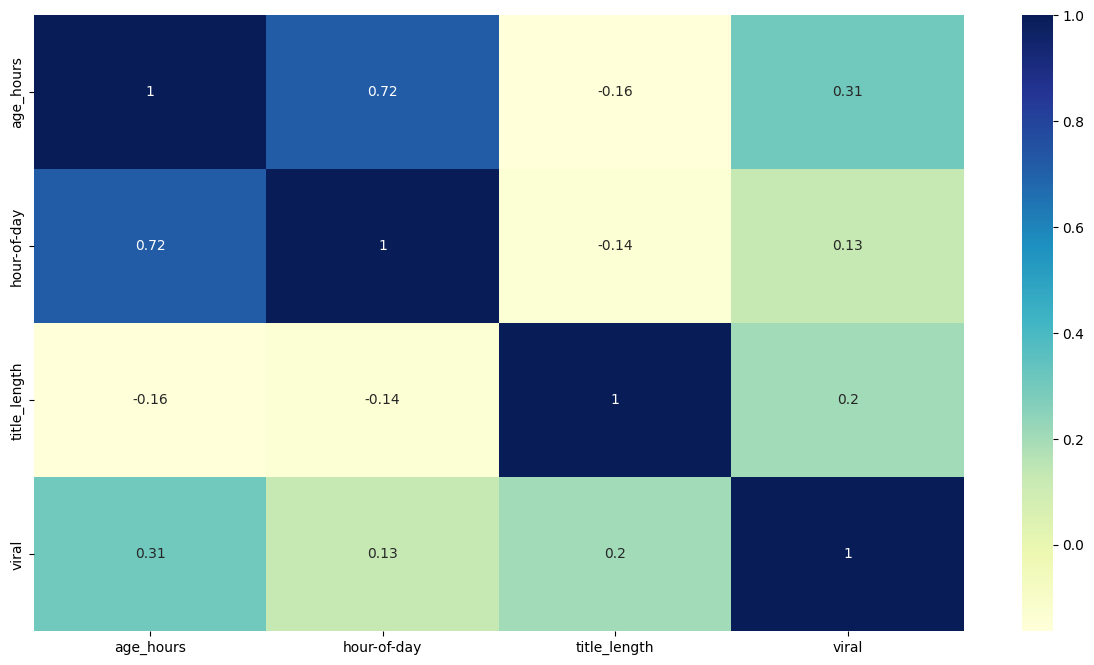

In [27]:
plt.figure(figsize=(15,8))
sns.heatmap(combined_df.select_dtypes(include=np.number).dropna().corr(), cmap="YlGnBu", annot=True)

In [29]:


combined_df.info()
combined_df.to_csv("cleaned_combined_posts.csv", index = True)


<class 'pandas.core.frame.DataFrame'>
Index: 15233 entries, 0 to 991
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subreddit     15233 non-null  object 
 1   title         15233 non-null  object 
 2   age_hours     15233 non-null  float64
 3   hour-of-day   15233 non-null  int32  
 4   day-of-week   15233 non-null  object 
 5   title_length  15233 non-null  int64  
 6   viral         15233 non-null  int64  
dtypes: float64(1), int32(1), int64(2), object(3)
memory usage: 892.6+ KB


In [31]:
df = pd.read_csv("cleaned_combined_posts.csv")


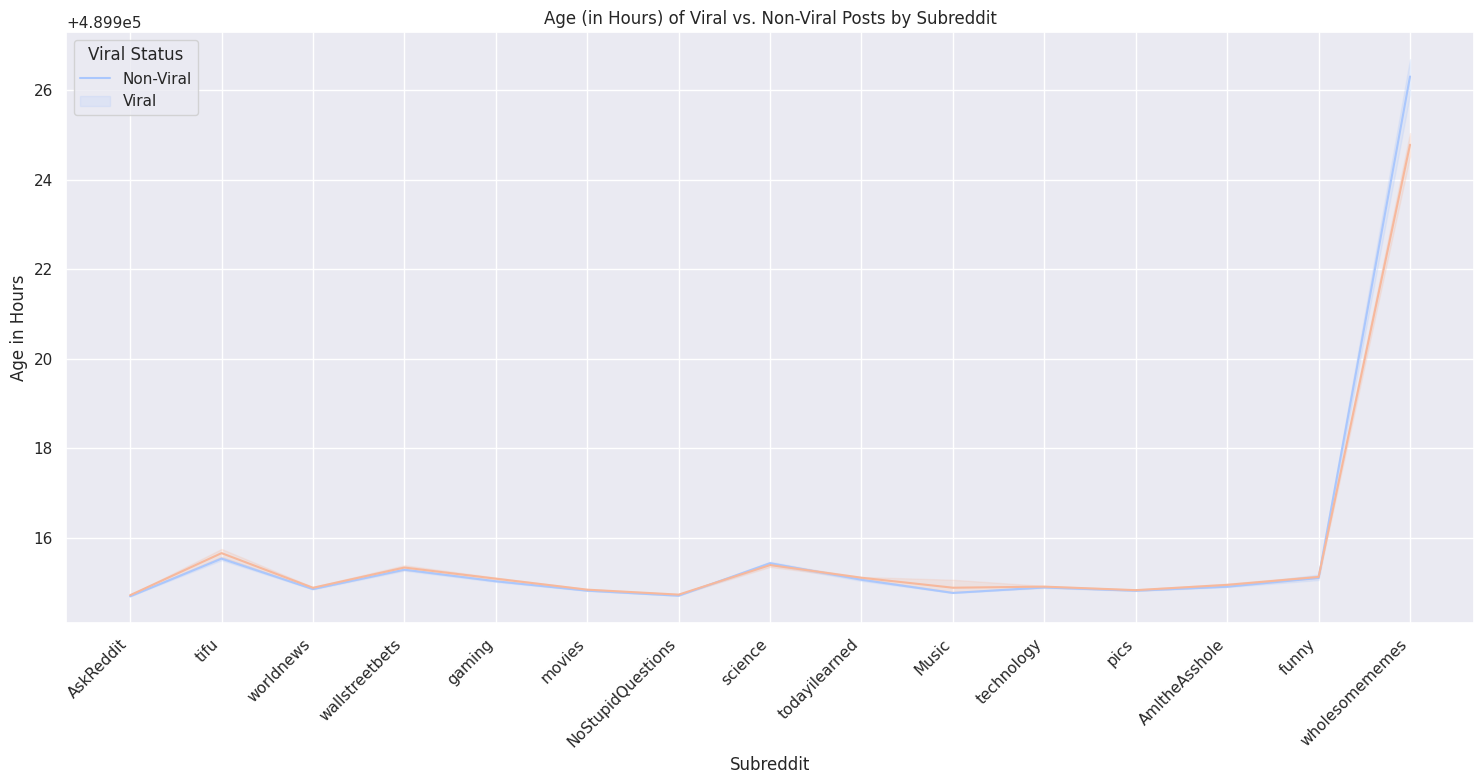

In [35]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df, x='subreddit', y='age_hours', hue='viral', palette='coolwarm')
plt.title('Age (in Hours) of Viral vs. Non-Viral Posts by Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Age in Hours')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Viral Status', labels=['Non-Viral', 'Viral'])
plt.tight_layout()
plt.show()

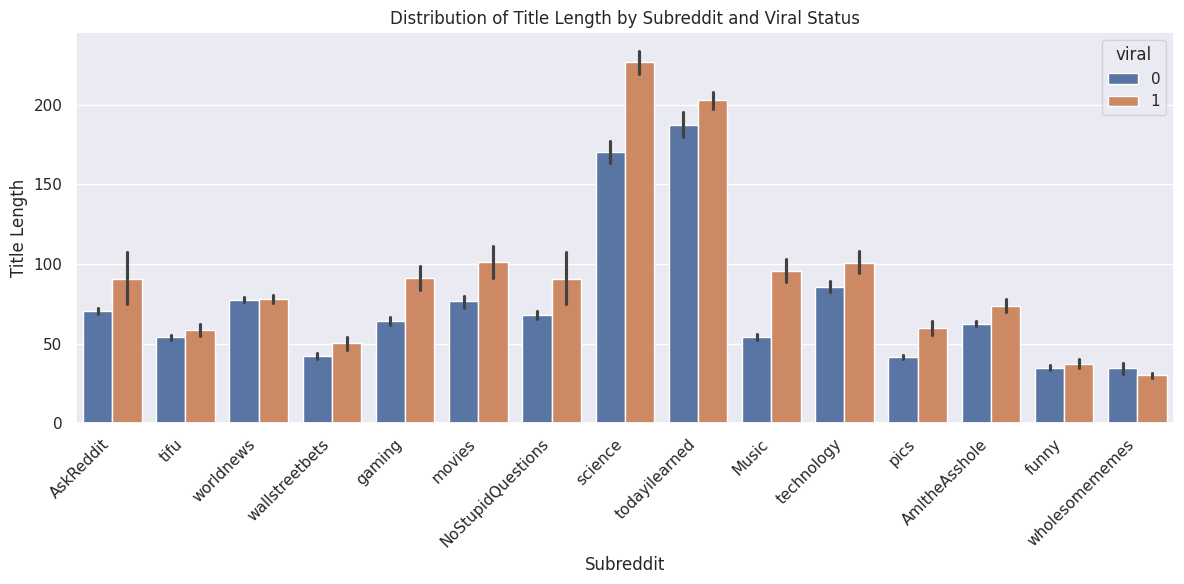

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(data = df, x= "subreddit",y = "title_length" , hue = "viral")
plt.title('Distribution of Title Length by Subreddit and Viral Status')
plt.xlabel('Subreddit')
plt.ylabel('Title Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


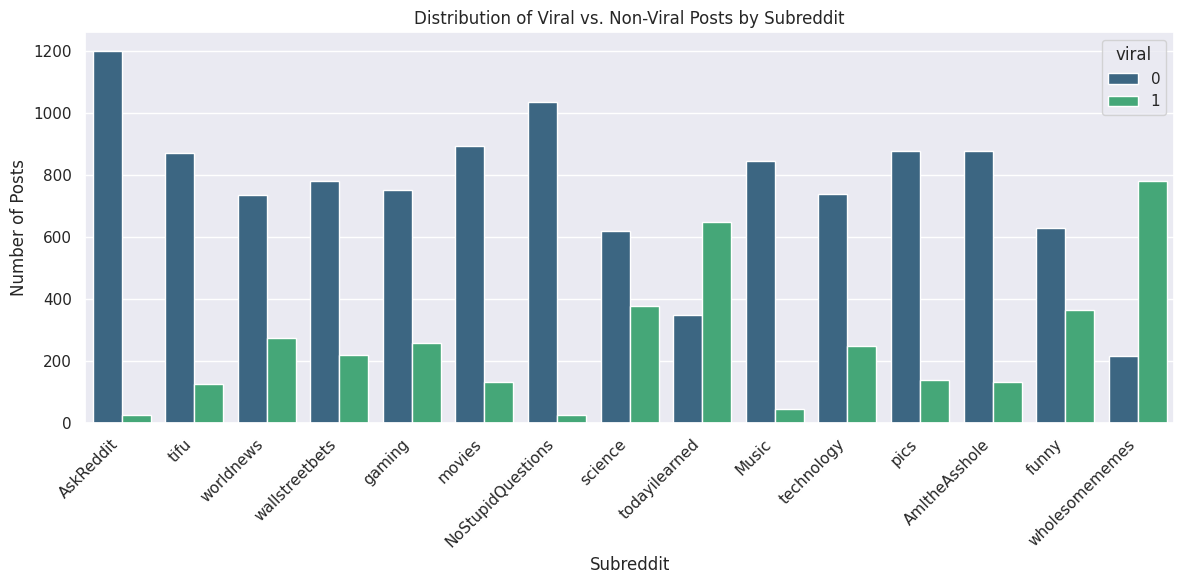

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='subreddit', hue='viral', palette='viridis')
plt.title('Distribution of Viral vs. Non-Viral Posts by Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()